Objective:

The objective of this assignment is to compare the performance of Light GBM and XG Boost algorithms using the Titanic dataset.

Exploratory Data Analysis (EDA):

1. Load the Titanic dataset using Python's pandas library.

2. Check for missing values.

3. Explore data distributions using histograms and box plots.

4. Visualize relationships between features and survival using scatter plots and bar plots.

Data Preprocessing:

1. Impute missing values.

2. Encode categorical variables using one-hot encoding or label encoding.

3. If needed you can apply more preprocessing methods on the given dataset.

Building Predictive Models:

1. Split the preprocessed dataset into training and testing sets.

2. Choose appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score) for model evaluation.

3. Build predictive models using LightGBM and XGBoost algorithms.

4. Train the models on the training set and evaluate their performance on the testing set.

5. Use techniques like cross-validation and hyperparameter tuning to optimize model performance.

Comparative Analysis:

1. Compare the performance metrics (e.g., accuracy, precision, recall) of LightGBM and XGBoost models.

2. Visualize and interpret the results to identify the strengths and weaknesses of each algorithm.

Submission Requirements:

Well-commented code explaining each step of the analysis.

Visualizations with appropriate titles and labels.

A brief report summarizing the comparative analysis results and practical implications.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

In [3]:
!pip install ppscore


  Preparing metadata (setup.py) ... done
  Created wheel for ppscore: filename=ppscore-1.3.1-py2.py3-none-any.whl size=13180 sha256=93deb9559afe17db953398277a0b4c2866e00d9bb07a569039d59f6223c78ed3
  Stored in directory: /root/.cache/pip/wheels/84/0d/d6/ec295c574356939e9877f87c4eb195ba97440b0cd97cadf32a
Successfully built ppscore


In [4]:
import ppscore as pps

In [5]:
df = pd.read_csv("adult_with_headers (1).csv")

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [6]:
df.shape

(32561, 15)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [8]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [9]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


In [18]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
print(df.columns)

Index(['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'capital_gain',
       'capital_loss', 'hours_per_week', 'native_country', 'income',
       'sex__male'],
      dtype='object')


In [10]:
df.replace(" ?", np.nan, inplace=True)

In [11]:


# Fill categorical with mode
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Fill numeric with mean
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].mean(), inplace=True)

print(df.isnull().sum())

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64


/tmp/ipykernel_883/1971754551.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_883/1971754551.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

In [12]:
df = pd.get_dummies(df, columns=['sex'], drop_first=True)

In [13]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,income,sex_ Male
0,39,6,77516,9,13,4,0,1,4,2174,0,40,38,0,True
1,50,5,83311,9,13,2,3,0,4,0,0,13,38,0,True
2,38,3,215646,11,9,0,5,1,4,0,0,40,38,0,True
3,53,3,234721,1,7,2,5,0,2,0,0,40,38,0,True
4,28,3,338409,9,13,2,9,5,2,0,0,40,4,0,False


In [14]:
scaler = StandardScaler()

num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = scaler.fit_transform(df[num_cols])

In [15]:
minmax = MinMaxScaler()

df[num_cols] = minmax.fit_transform(df[num_cols])

In [21]:
# Example features
if 'hours_per_week' in df.columns:
    df['age_hours_ratio'] = df['age'] / (df['hours_per_week'] + 1)
df['capital_total'] = df['capital_gain'] + df['capital_loss']

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,income,sex__male,age_hours_ratio,capital_total
0,0.301370,0.857143,0.044302,0.600000,0.800000,0.666667,0.000000,0.2,1.0,0.02174,0.0,0.397959,0.95,0.0,True,0.215578,0.02174
1,0.452055,0.714286,0.048238,0.600000,0.800000,0.333333,0.230769,0.0,1.0,0.00000,0.0,0.122449,0.95,0.0,True,0.402740,0.00000
2,0.287671,0.428571,0.138113,0.733333,0.533333,0.000000,0.384615,0.2,1.0,0.00000,0.0,0.397959,0.95,0.0,True,0.205779,0.00000
3,0.493151,0.428571,0.151068,0.066667,0.400000,0.333333,0.384615,0.0,0.5,0.00000,0.0,0.397959,0.95,0.0,True,0.352765,0.00000
4,0.150685,0.428571,0.221488,0.600000,0.800000,0.333333,0.692308,1.0,0.5,0.00000,0.0,0.397959,0.10,0.0,False,0.107789,0.00000


In [22]:
print(df.skew().sort_values(ascending=False))

capital_gain       11.953848
capital_total       4.971783
capital_loss        4.594629
fnlwgt              1.446980
income              1.212430
age_hours_ratio     0.936125
relationship        0.786818
age                 0.558743
hours_per_week      0.227643
workclass           0.076469
occupation          0.000565
marital_status     -0.013508
education_num      -0.311676
sex__male          -0.719293
education          -0.934042
race               -2.435386
native_country     -4.243158
dtype: float64


In [24]:
print("Before:", df['capital_gain'].skew())

df['capital_gain_log'] = np.log1p(df['capital_gain'])

print("After:", df['capital_gain_log'].skew())

Before: 11.953847687699781
After: 10.671437107617788


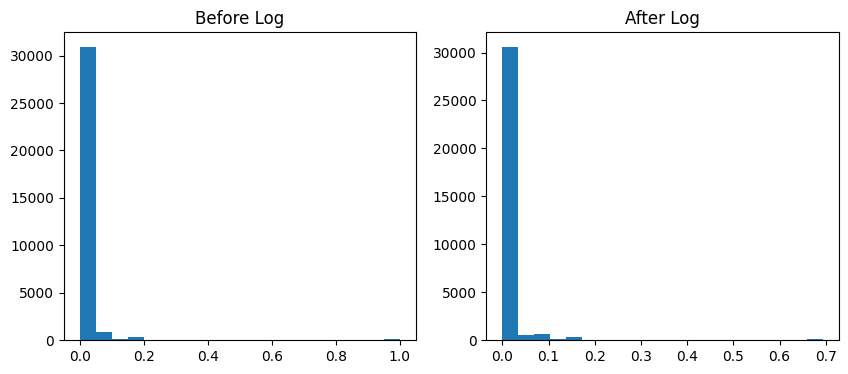

In [26]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(df['capital_gain'], bins=20)
plt.title("Before Log")

plt.subplot(1,2,2)
plt.hist(df['capital_gain_log'], bins=20)
plt.title("After Log")

plt.show()

Conclusion

In this assignment, data preprocessing and feature engineering techniques were applied to the Adult dataset. Missing values were handled using appropriate imputation methods, numerical features were scaled using Standard Scaling and Min-Max Scaling, and categorical variables were encoded using One-Hot Encoding and Label Encoding.

New features such as age group and work intensity were created to improve model representation, and log transformation was applied to reduce skewness. Isolation Forest was used for outlier detection, and PPS score analysis was performed to understand feature relationships.

These preprocessing steps help improve the quality of data and enhance the performance of machine learning models.